# Graphlet train/valid generalization gap — all stations, all datasets

Loads the dumped LSTM/Transformer predictions (`{graph}_{method}_{station}_train.csv`)
that are fed to the graphlet model as neighbor features, and compares the base
model's RMSE on the first `train_split` portion (used for gradient updates) vs. the
remaining portion (validation / held-out). A ratio `valid_rmse / train_rmse` much
larger than 1 indicates the graphlet's training-time neighbor features are
systematically easier than its test-time features — a potential stacking leak.

All helpers are defined in `diagnose_graphlet_leakage.py`; this notebook just
calls them and inlines the saved figures.

Prereq: run evaluation first so the `_train.csv` dumps exist under
`swissrivernetwork/benchmark/dump/predictions/<path_extra_keys>/`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from swissrivernetwork.benchmark.dataset import PROJ_DIR, read_stations
from swissrivernetwork.benchmark.visualize_results.diagnose_graphlet_leakage import (
    FIG_DIR,
    analyze_graph,
    _plot_ratio_bars,
    _plot_time_series_grid,
)

FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# --- Configuration ---
METHOD = "lstm"  # 'lstm' or 'transformer'
PATH_EXTRA_KEYS = "-fs7-future_embedding-wl90-none"  # same suffix as get_run_extra_key(config)
TRAIN_SPLIT = 0.8
GRAPHS = ["swiss-1990", "swiss-2010", "zurich"]

predict_dump_dir = (
    Path(PROJ_DIR) / "swissrivernetwork" / "benchmark" / "dump" / "predictions" / PATH_EXTRA_KEYS
)
tag = PATH_EXTRA_KEYS.strip("-") or "root"
print(f"predict_dump_dir = {predict_dump_dir}")
print(f"exists           = {predict_dump_dir.is_dir()}")

predict_dump_dir = ~/codes/swiss-river-network-benchmark/swissrivernetwork/benchmark/dump/predictions/-fs7-future_embedding-wl90-none
exists           = True


In [3]:
# --- Run diagnostic over all stations of all 3 datasets ---
all_summary: list[dict] = []
per_graph_details: dict[str, dict] = {}

for graph in GRAPHS:
    stations = read_stations(graph)
    print(f"\n========== {graph} ({len(stations)} stations) ==========")
    summary, per_station = analyze_graph(
        graph, stations, METHOD, predict_dump_dir, TRAIN_SPLIT, verbose=False
    )
    if not summary:
        print(f"  no usable stations for {graph}")
        continue
    all_summary.extend(summary)
    per_graph_details[graph] = per_station
    df_g = pd.DataFrame(summary)
    print(
        f"  median ratio={df_g['ratio'].median():.2f}  "
        f"max ratio={df_g['ratio'].max():.2f}  "
        f">2x: {(df_g['ratio'] > 2.0).sum()}  >1.3x: {(df_g['ratio'] > 1.3).sum()}"
    )

df_summary = pd.DataFrame(all_summary)
df_summary.sort_values(["graph_name", "ratio"], ascending=[True, False], inplace=True)
df_summary.reset_index(drop=True, inplace=True)
df_summary.head(20)


========== swiss-1990 (28 stations) ==========
  median ratio=1.14  max ratio=1.89  >2x: 0  >1.3x: 10

========== swiss-2010 (63 stations) ==========
  median ratio=1.01  max ratio=1.35  >2x: 0  >1.3x: 1

========== zurich (15 stations) ==========
  median ratio=0.93  max ratio=1.04  >2x: 0  >1.3x: 0


,graph_name,station,method,train_rmse_norm,valid_rmse_norm,train_mae_norm,valid_mae_norm,ratio,n_train,n_valid
0,swiss-1990,2029,lstm,0.069145,0.130540,0.043687,0.077442,1.887909,6336,1584
1,swiss-1990,2243,lstm,0.069233,0.116960,0.047698,0.075136,1.689365,6336,1584
2,swiss-1990,2500,lstm,0.084356,0.139645,0.062589,0.096843,1.655426,6336,1584
3,swiss-1990,2070,lstm,0.089041,0.145349,0.064781,0.100476,1.632376,6336,1584
4,swiss-1990,2044,lstm,0.091579,0.142199,0.067136,0.099536,1.552738,6336,1584
5,swiss-1990,2018,lstm,0.071324,0.109424,0.051181,0.072987,1.534186,6336,1584
6,swiss-1990,2104,lstm,0.072748,0.111395,0.048907,0.073568,1.531247,6336,1584
7,swiss-1990,2019,lstm,0.104484,0.151113,0.081331,0.111453,1.446271,6336,1584
8,swiss-1990,2372,lstm,0.083399,0.114782,0.064691,0.084550,1.376299,6336,1584
9,swiss-1990,2109,lstm,0.097242,0.129326,0.075675,0.101032,1.329928,6336,1584


In [4]:
# --- Per-graph aggregate statistics ---
df_summary.groupby("graph_name").agg(
    n=("station", "count"),
    median_ratio=("ratio", "median"),
    max_ratio=("ratio", "max"),
    n_above_1p3=("ratio", lambda s: int((s > 1.3).sum())),
    n_above_2p0=("ratio", lambda s: int((s > 2.0).sum())),
)

,n,median_ratio,max_ratio,n_above_1p3,n_above_2p0
graph_name,,,,,
swiss-1990,28,1.138633,1.887909,10,0
swiss-2010,63,1.007615,1.352197,1,0
zurich,15,0.925298,1.037496,0,0


## Ratio bar chart (per station, grouped by dataset)

Green bars: `no gap` (ratio ≤ 1.3). Orange: `mild gap` (1.3 < ratio ≤ 2). Red:
`strong leakage` (ratio > 2). Horizontal lines mark the thresholds.

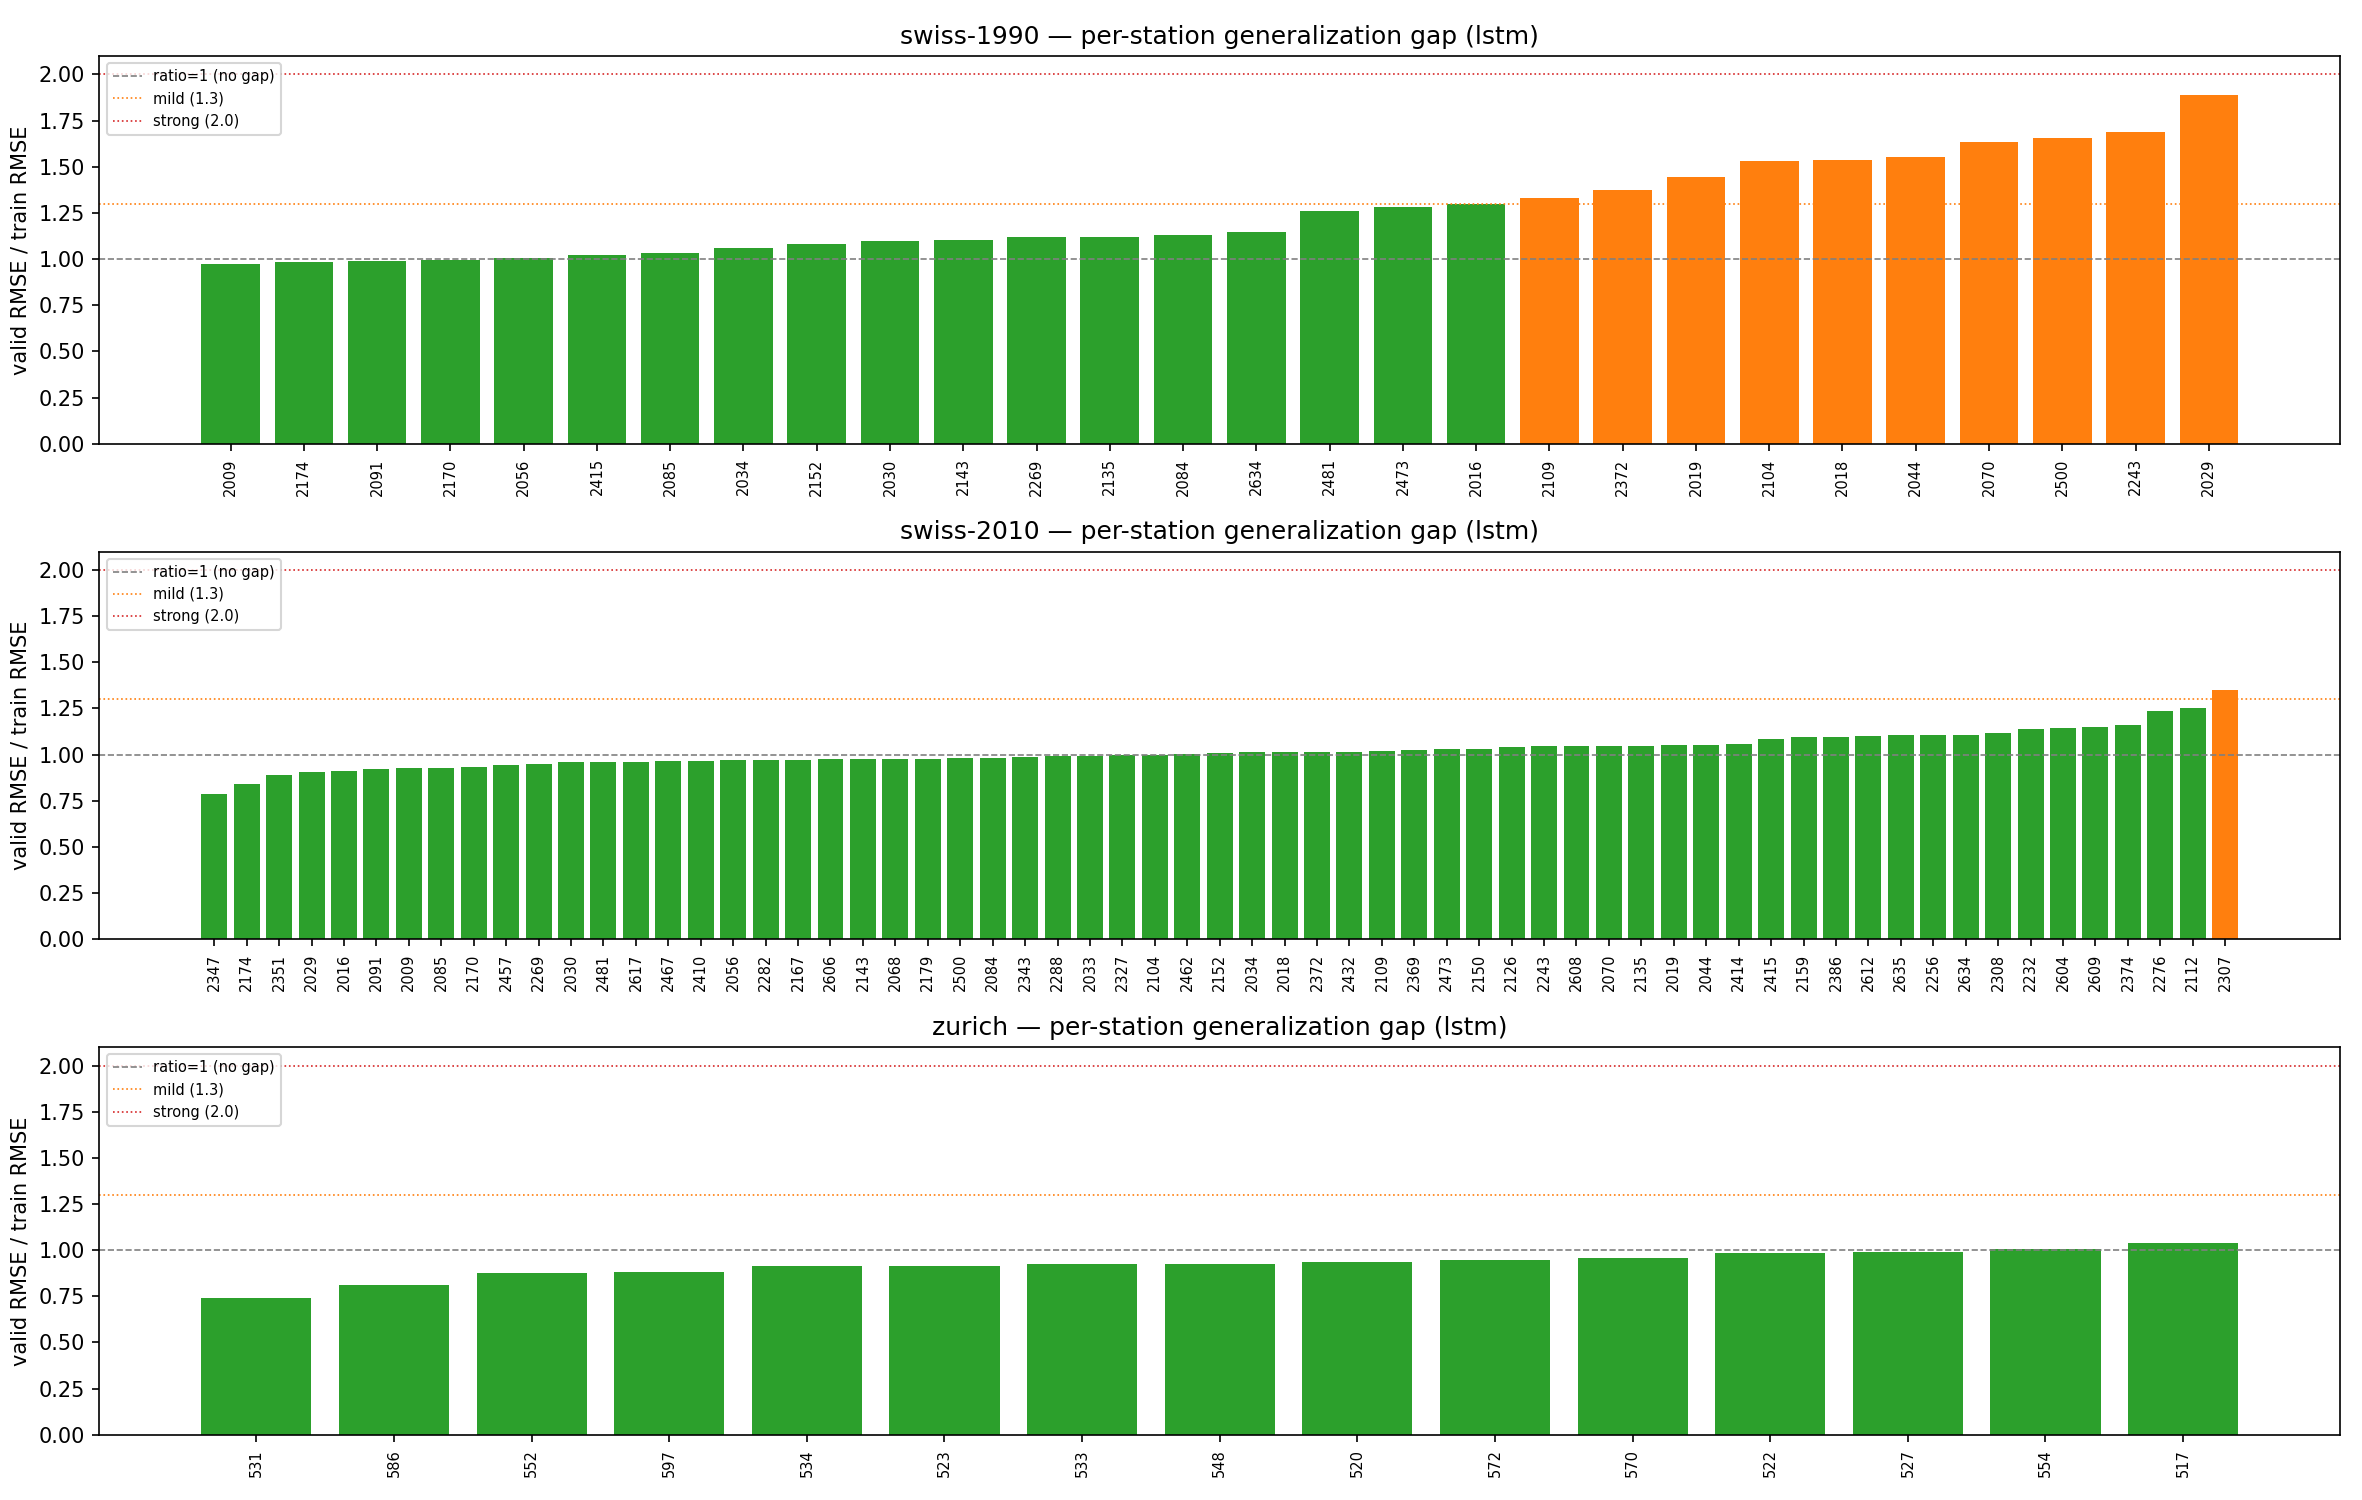

In [5]:
bar_path = FIG_DIR / f"leakage_{tag}_{METHOD}_ratios.png"
_plot_ratio_bars(all_summary, bar_path)
display(Image(filename=str(bar_path)))

## Per-dataset time-series grids

For each dataset, up to 12 stations are plotted. Blue = absolute error on each
epoch day; red = rolling mean; dashed vertical line = the 80/20 epoch-day cutoff
(train portion on the left, valid portion on the right). If the red curve jumps
visibly to the right of the dashed line, the base model's predictions there are
materially worse than on the train portion.

--- swiss-1990 ---  (leakage_fs7-future_embedding-wl90-none_swiss-1990_lstm_timeseries.png)


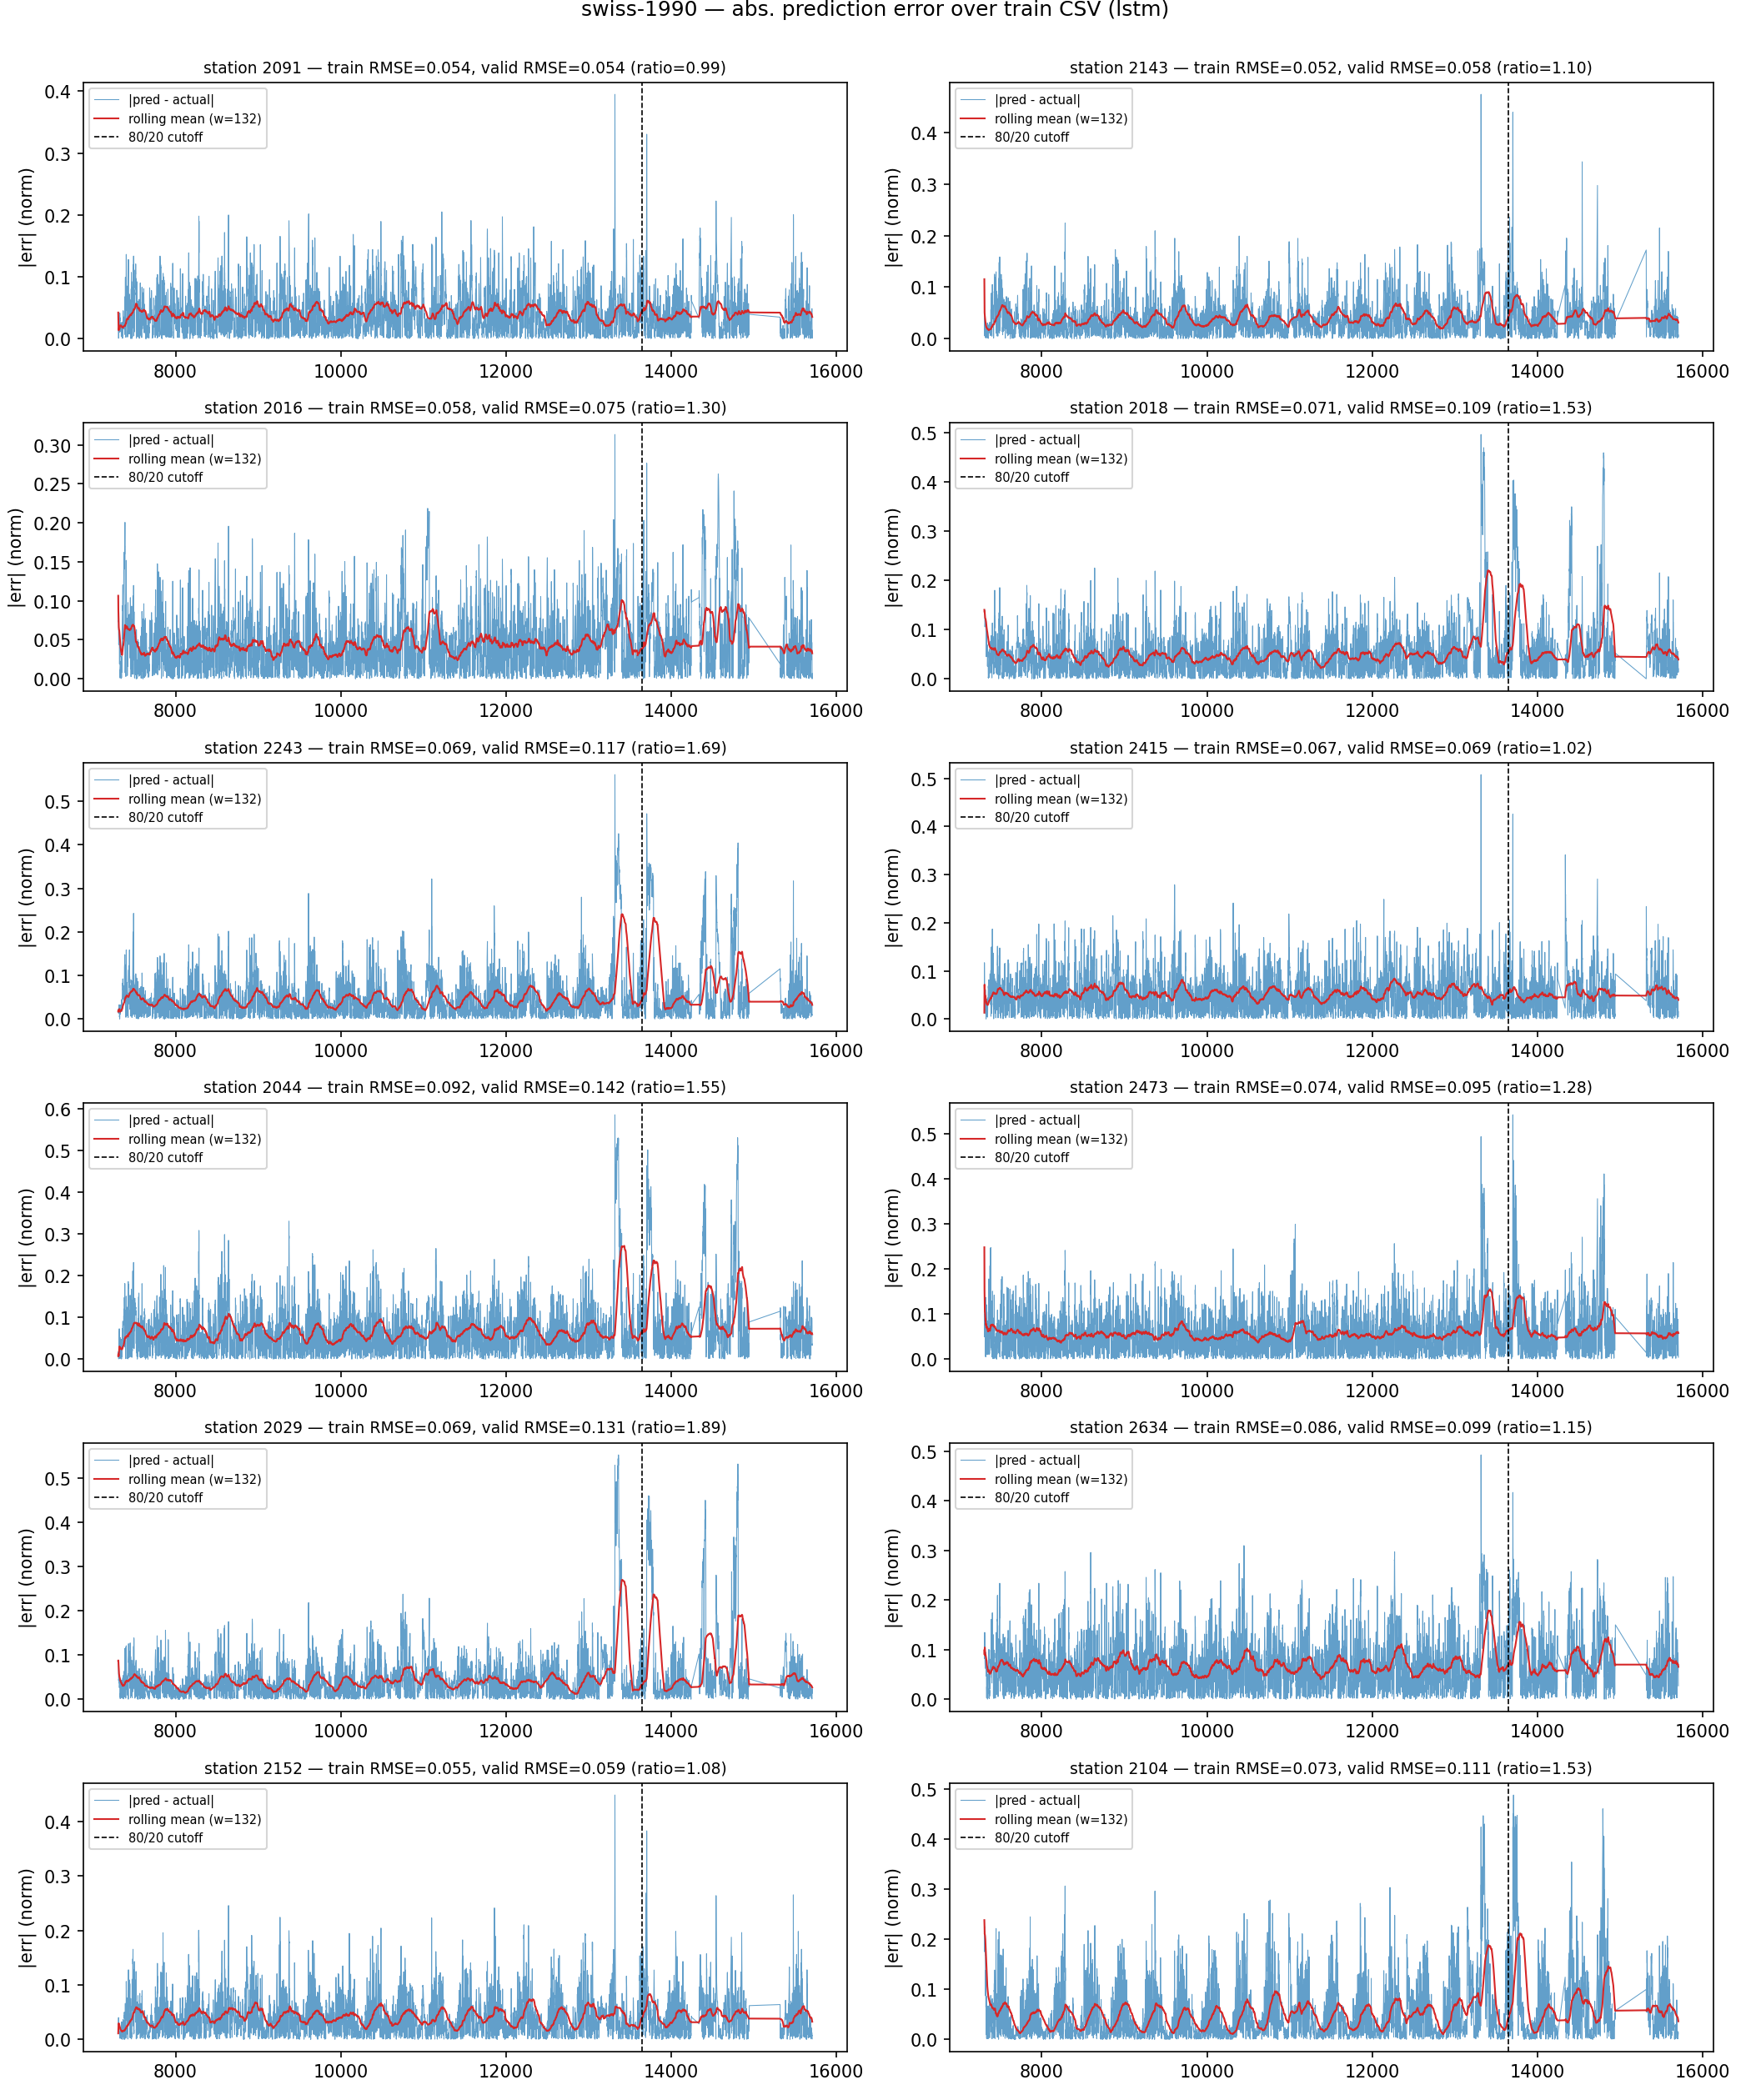

--- swiss-2010 ---  (leakage_fs7-future_embedding-wl90-none_swiss-2010_lstm_timeseries.png)


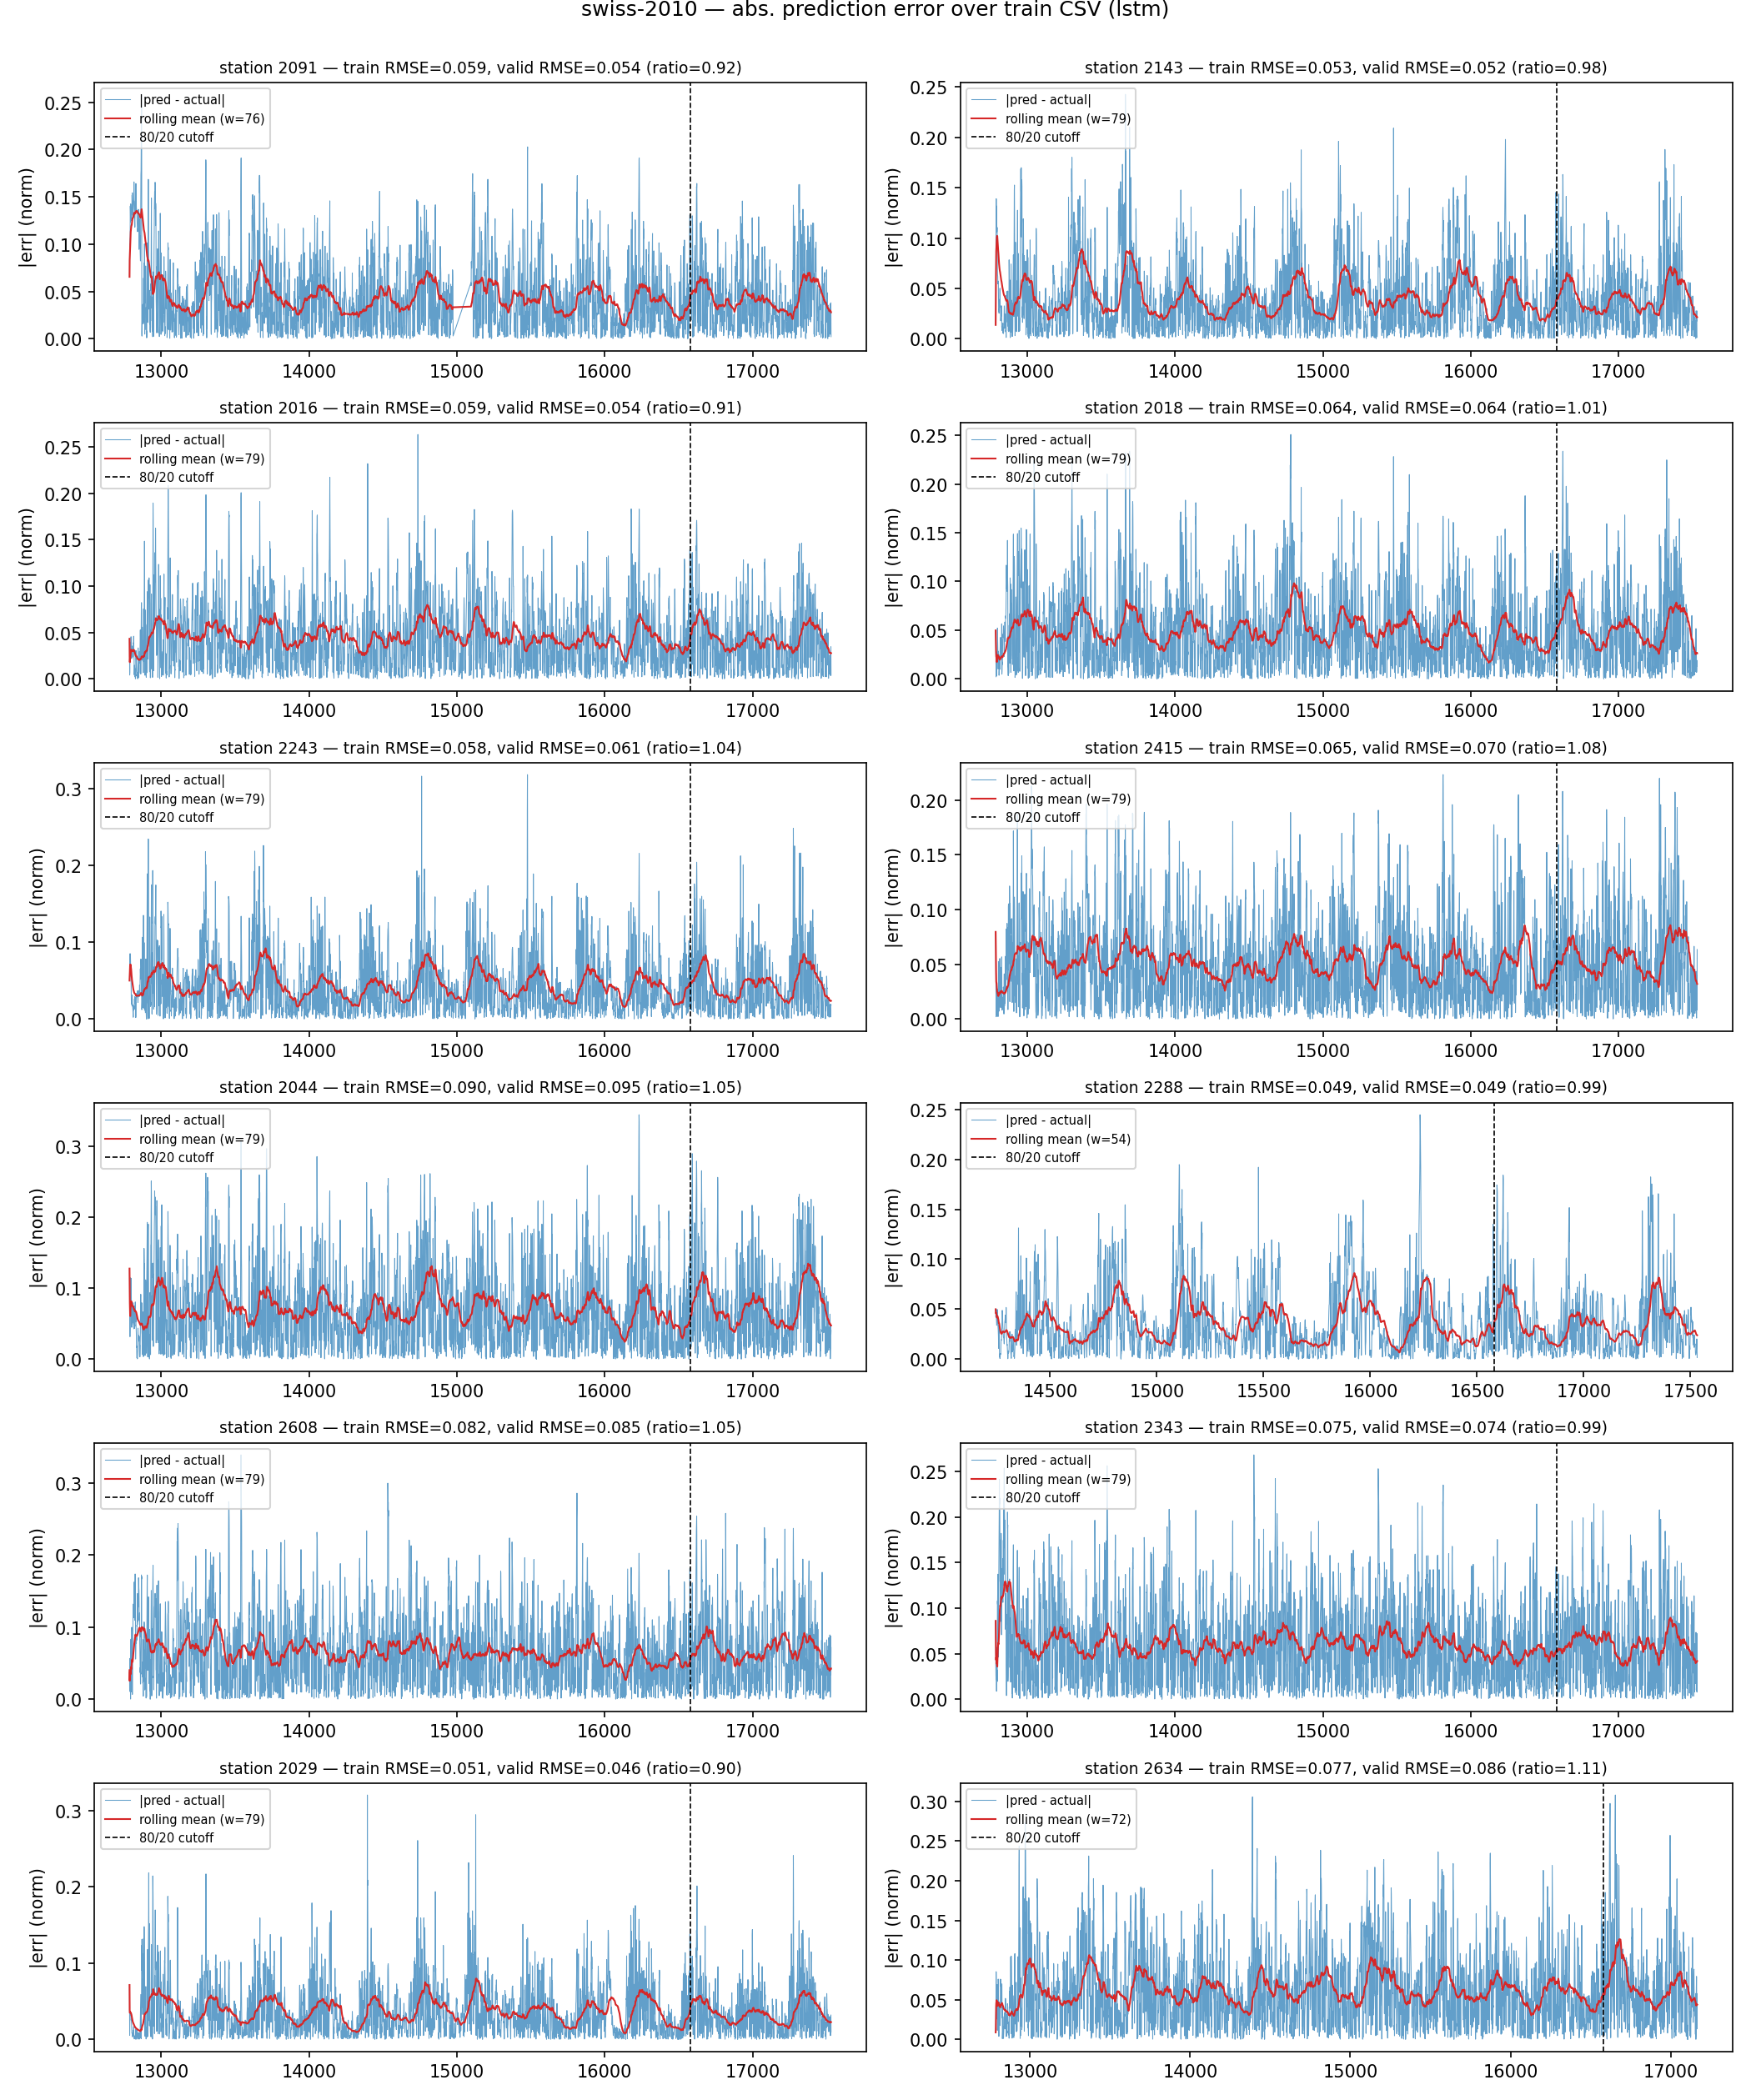

--- zurich ---  (leakage_fs7-future_embedding-wl90-none_zurich_lstm_timeseries.png)


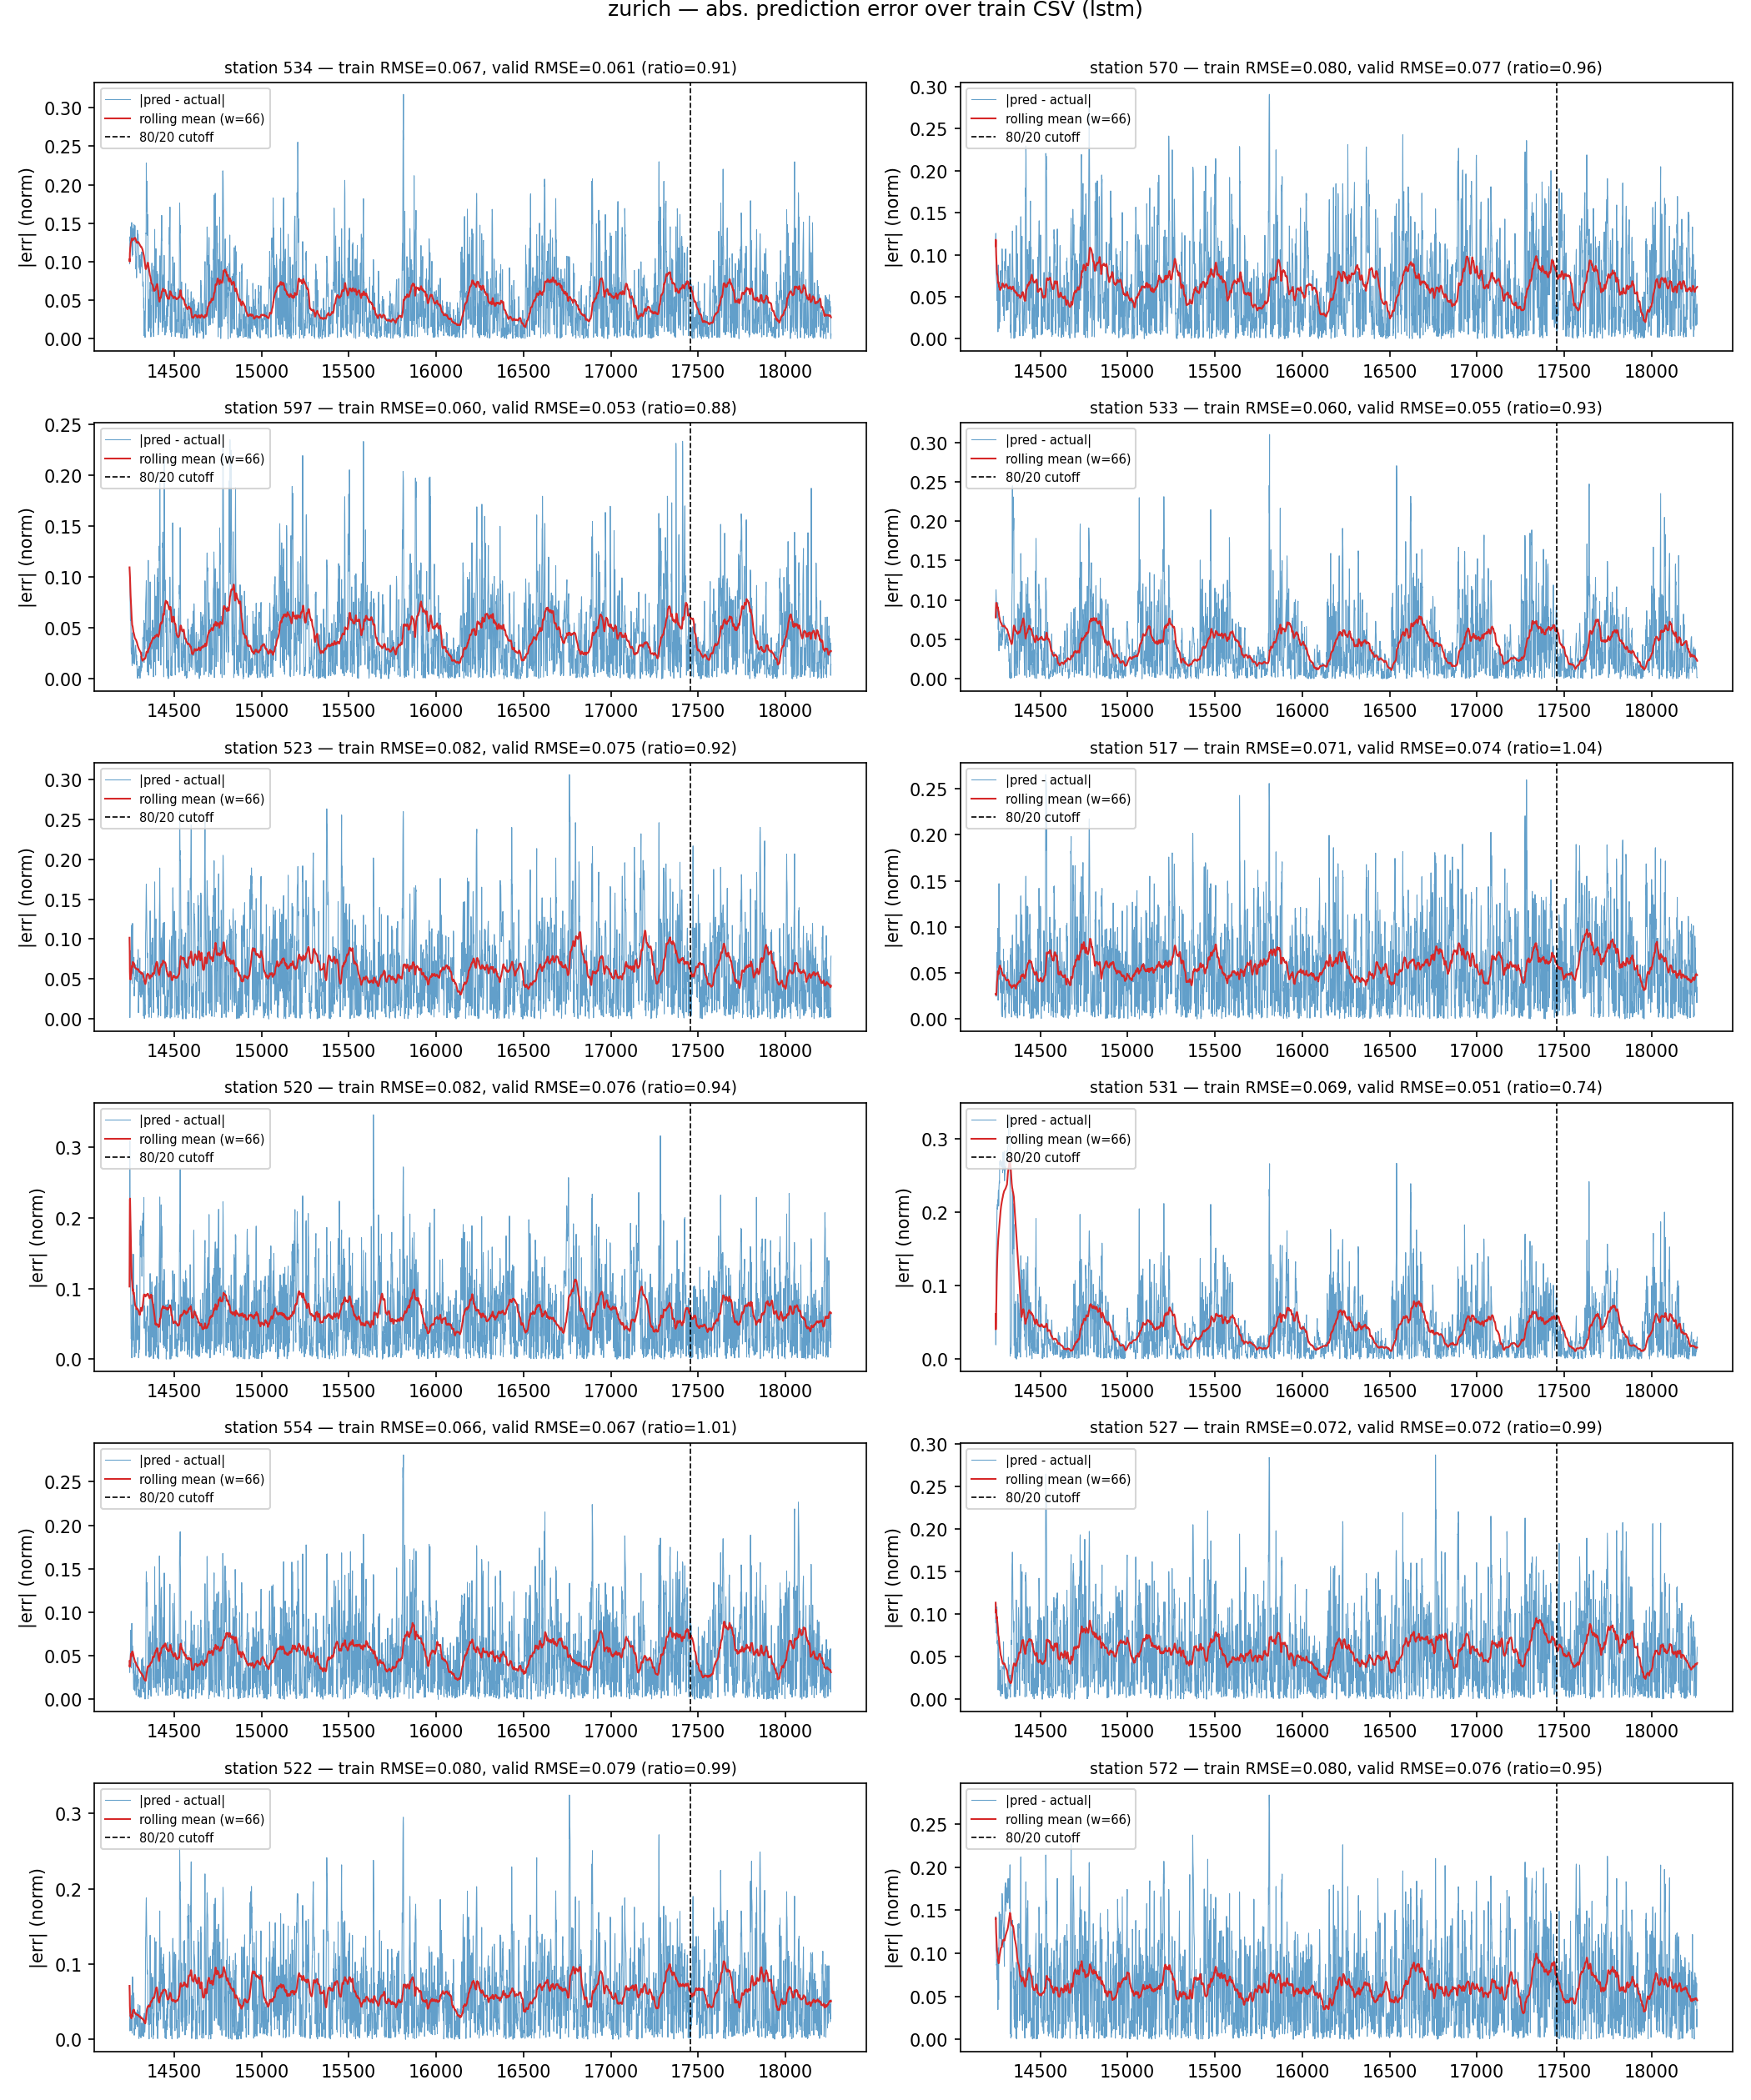

In [6]:
for graph, per_station in per_graph_details.items():
    ts_path = FIG_DIR / f"leakage_{tag}_{graph}_{METHOD}_timeseries.png"
    _plot_time_series_grid(graph, METHOD, per_station, ts_path, max_stations=12)
    print(f"--- {graph} ---  ({ts_path.name})")
    display(Image(filename=str(ts_path)))

In [7]:
# --- Write the per-station summary CSV ---
csv_path = FIG_DIR / f"leakage_{tag}_{METHOD}_summary.csv"
df_summary.to_csv(csv_path, index=False)
print(f"wrote {csv_path}")

wrote ~/codes/swiss-river-network-benchmark/swissrivernetwork/benchmark/visualize_results/figures/leakage_fs7-future_embedding-wl90-none_lstm_summary.csv


## Cross-configuration comparison — LSTM vs Transformer, forecasting vs nowcasting

Loads the four summary CSVs that `diagnose_graphlet_leakage.py` writes for the
standard configurations and stacks them into a single view. Run this AFTER all
four runs have been produced — otherwise missing files are printed and skipped.

- LSTM forecasting: `-fs7-future_embedding-wl90-none`
- LSTM nowcasting: `-wl90-none`
- Transformer forecasting: `-fs7-wl90-rope`
- Transformer nowcasting: `-wl90-rope`

Edit `CONFIGS` below to point to different path-extra-keys (e.g. sinusoidal or
learnable PE) without touching the rest of the notebook.

In [ ]:
# --- Load all four summary CSVs and stack ---
CONFIGS = {
    ("lstm", "forecasting"): "leakage_fs7-future_embedding-wl90-none_lstm_summary.csv",
    ("lstm", "nowcasting"): "leakage_wl90-none_lstm_summary.csv",
    ("transformer", "forecasting"): "leakage_fs7-wl90-rope_transformer_summary.csv",
    ("transformer", "nowcasting"): "leakage_wl90-rope_transformer_summary.csv",
}

rows: list[dict] = []
for (m, task), fname in CONFIGS.items():
    p = FIG_DIR / fname
    if not p.is_file():
        print(f"MISSING: {fname} - skip")
        continue
    df = pd.read_csv(p)
    for graph, g in df.groupby("graph_name"):
        rows.append(
            {
                "method": m,
                "task": task,
                "graph": graph,
                "n": len(g),
                "median_ratio": round(g["ratio"].median(), 3),
                "max_ratio": round(g["ratio"].max(), 3),
                "n_above_1p3": int((g["ratio"] > 1.3).sum()),
                "n_above_2p0": int((g["ratio"] > 2.0).sum()),
            }
        )

cmp_df = pd.DataFrame(rows).sort_values(["task", "method", "graph"]).reset_index(drop=True)
cmp_df

### Pivoted view: median ratio per `(task, method) × graph`

In [ ]:
cmp_df.pivot_table(
    index=["task", "method"],
    columns="graph",
    values="median_ratio",
    aggfunc="first",
)

### Pivoted view: count of stations with `ratio > 2` (strong leakage signal)

In [ ]:
cmp_df.pivot_table(
    index=["task", "method"],
    columns="graph",
    values="n_above_2p0",
    aggfunc="first",
    fill_value=0,
)